In [1]:
!pip install mikeio pathlib matplotlib

Defaulting to user installation because normal site-packages is not writeable


Processing Jan-Feb23.dfsu ...
Processing Mar-Apr23.dfsu ...
Processing May-Jun23.dfsu ...
Processing Jul-Aug23.dfsu ...
Processing Sep-Oct23.dfsu ...
Processing Nov-Dec23.dfsu ...
✅ Saved: C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Salinity_timeseries_2023.csv


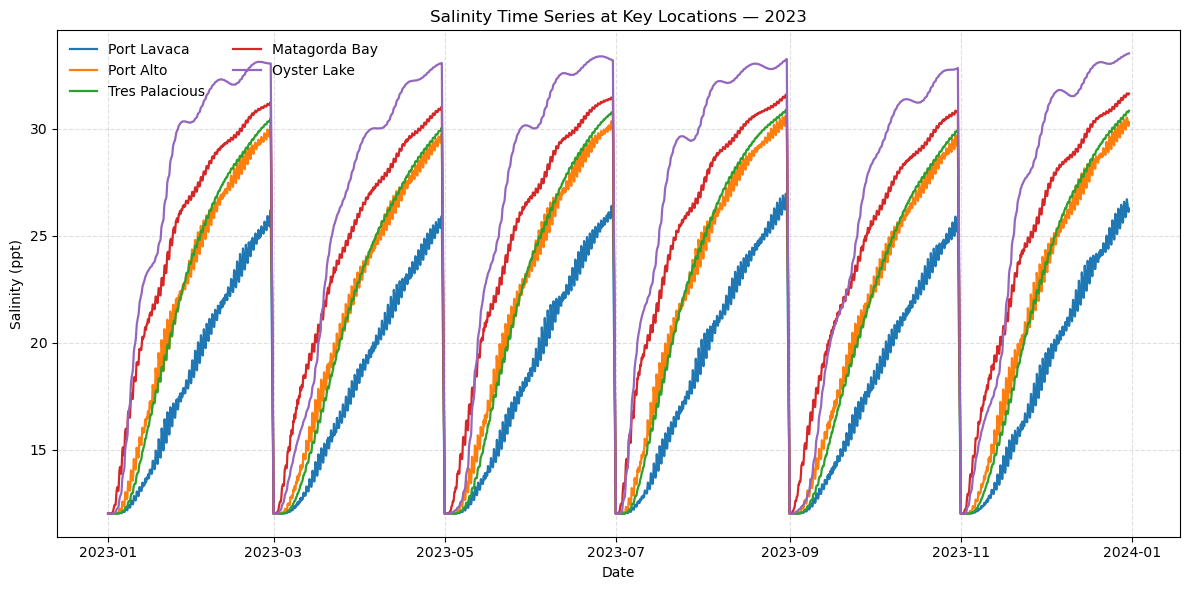

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mikeio import Dfsu

# ------------------ USER INPUTS ------------------
dfsu_files = [
    r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Jan-Feb23.dfsu",
    r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Mar-Apr23.dfsu",
    r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\May-Jun23.dfsu",
    r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Jul-Aug23.dfsu",
    r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Sep-Oct23.dfsu",
    r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Nov-Dec23.dfsu",
]

# Station coordinates (UTM Zone 14N; meters)
stations = {
    "Port Lavaca":     (736632, 3167578),
    "Port Alto":       (755087, 3172314),
    "Tres Palacious":  (770727, 3175616),
    "Matagorda Bay":   (759847, 3162280),
    "Oyster Lake":     (775165, 3168506),
}

item_hint = "salin"  # fuzzy match; matches "Salinity", "Mean Salinity", etc.
out_csv   = r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Salinity_timeseries_2023.csv"

# ------------------ HELPERS ------------------
def find_item_index(dfsu, hint="salin"):
    names = [it.name for it in dfsu.items]
    idxs = [i for i, n in enumerate(names) if hint.lower() in n.lower()]
    if not idxs:
        raise ValueError(f"No item containing '{hint}' found. Items: {names}")
    return idxs[0]

def read_segment_ts_for_stations(path, stations_dict, n_nearest=4, extrapolate=True):
    """Return DataFrame (time x stations) for one DFSU file."""
    dfsu = Dfsu(path)
    it = find_item_index(dfsu, item_hint)
    ds = dfsu.read(items=it)     # Dataset with one DataArray (salinity)
    da = ds[0]                   # DataArray (time x elements)

    cols = {}
    for name, (x, y) in stations_dict.items():
        da_pt = da.interp(x=float(x), y=float(y), n_nearest=n_nearest, extrapolate=extrapolate)  # DataArray (time,)
        # Convert to pandas Series with time index
        try:
            s = da_pt.to_pandas()  # preferred in mikeio
        except AttributeError:
            # Fallback for very old versions
            s = pd.Series(da_pt.to_numpy(), index=ds.time, name=name)
        s.name = name
        cols[name] = s

    # Align into a single DataFrame
    df = pd.DataFrame(cols)
    df.index.name = "time"
    return df

# ------------------ MAIN ------------------
pieces = []
for f in dfsu_files:
    print(f"Processing {Path(f).name} ...")
    seg_df = read_segment_ts_for_stations(f, stations, n_nearest=4, extrapolate=True)
    pieces.append(seg_df)

# Concatenate in time, sort, and drop duplicate timestamps at segment seams
sal_2023 = pd.concat(pieces).sort_index()
sal_2023 = sal_2023[~sal_2023.index.duplicated(keep="first")]

# Save & Plot
sal_2023.to_csv(out_csv)
print(f"✅ Saved: {out_csv}")

plt.figure(figsize=(12, 6))
for col in sal_2023.columns:
    plt.plot(sal_2023.index, sal_2023[col], label=col, linewidth=1.6)
plt.title("Salinity Time Series at Key Locations — 2023")
plt.xlabel("Date"); plt.ylabel("Salinity (ppt)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()



✅ Monthly means saved: C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Salinity_monthly_means_2023.csv


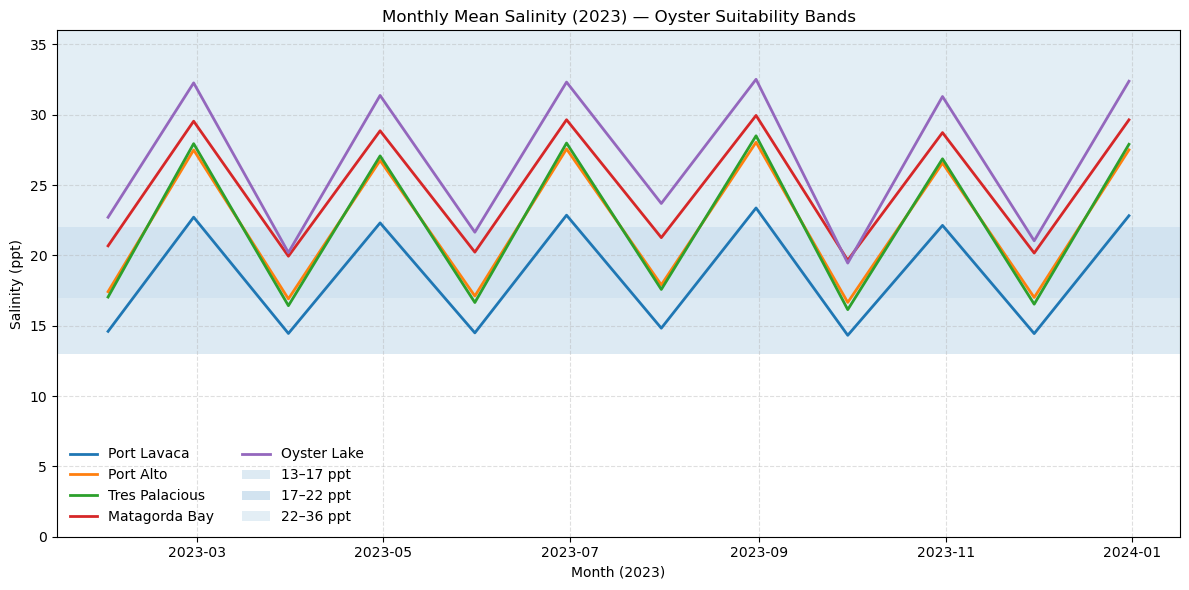

In [6]:
# ====================== MONTHLY MEANS + SHADED BANDS ======================
import pandas as pd
import matplotlib.pyplot as plt

# 1) Monthly means for each site
sal_monthly = sal_2023.resample("M").mean()

# Optional: save monthly means
sal_monthly_out = r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Salinity_monthly_means_2023.csv"
sal_monthly.to_csv(sal_monthly_out)
print(f"✅ Monthly means saved: {sal_monthly_out}")

# 2) Plot: monthly means with oyster-suitability bands
plt.figure(figsize=(12, 6))

# Shaded suitability bands (draw first so lines appear on top)
plt.axhspan(13, 17, alpha=0.15, label="13–17 ppt (sub-optimal)")
plt.axhspan(17, 22, alpha=0.20, label="17–22 ppt (optimal)")
plt.axhspan(22, 36, alpha=0.12, label="22–36 ppt (tolerable upper)")

# Plot all sites
for col in sal_monthly.columns:
    plt.plot(sal_monthly.index, sal_monthly[col], linewidth=2, label=col)

plt.title("Monthly Mean Salinity (2023) — Oyster Suitability Bands")
plt.xlabel("Month (2023)")
plt.ylabel("Salinity (ppt)")
plt.grid(True, linestyle="--", alpha=0.4)

# Build a clean legend:
# First, handles for lines (sites), then add custom patches for bands
handles, labels = plt.gca().get_legend_handles_labels()
# Keep only site labels (unique) and append band legend entries manually
# To avoid duplicate band labels from axhspan, we create proxy artists:
import matplotlib.patches as mpatches
band1 = mpatches.Patch(alpha=0.15, label="13–17 ppt (sub-optimal)")
band2 = mpatches.Patch(alpha=0.20, label="17–22 ppt (optimal)")
band3 = mpatches.Patch(alpha=0.12, label="22–36 ppt (tolerable upper)")

# Filter out duplicate band labels from auto-legend
site_handles = []
site_labels  = []
for h, l in zip(handles, labels):
    if l in sal_monthly.columns:  # only keep site lines
        site_handles.append(h)
        site_labels.append(l)

plt.legend(
    site_handles + [band1, band2, band3],
    site_labels  + ["13–17 ppt", "17–22 ppt", "22–36 ppt"],
    ncol=2, frameon=False
)

plt.ylim(0, max(36, float(sal_monthly.max().max()) + 2))  # headroom
plt.tight_layout()
plt.show()


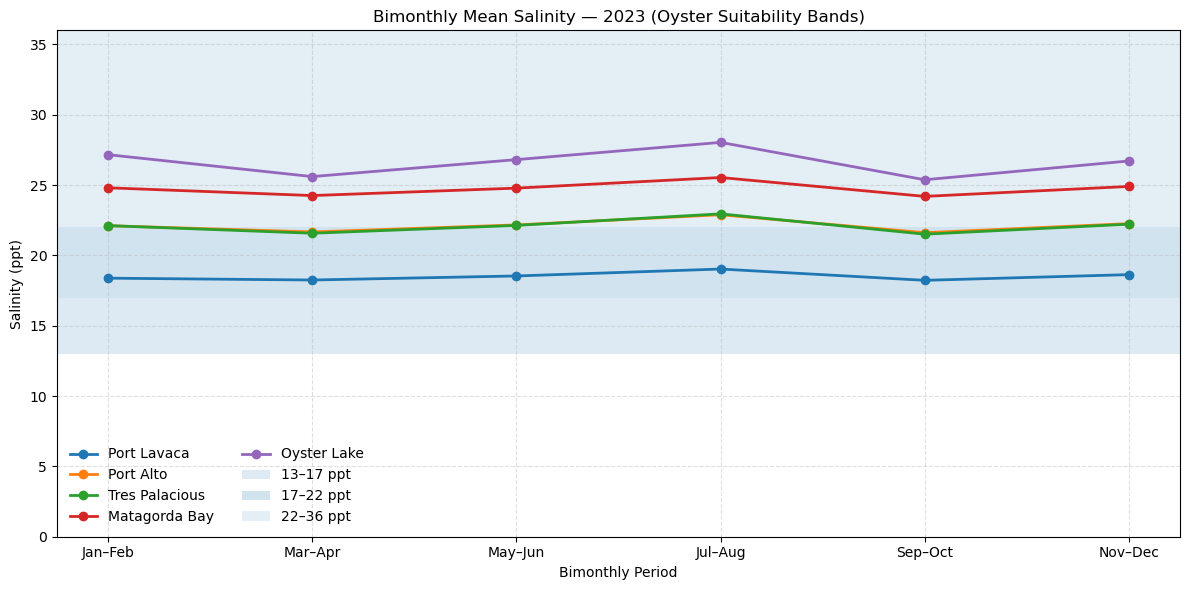

In [8]:
# -------------------------------------------------------------
# 3) Plot with oyster-suitability bands (fixed legend)
# -------------------------------------------------------------
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Shaded bands (draw first, behind lines)
p1 = plt.axhspan(13, 17, alpha=0.15, zorder=0)
p2 = plt.axhspan(17, 22, alpha=0.20, zorder=0)
p3 = plt.axhspan(22, 36, alpha=0.12, zorder=0)

# Plot each site and collect line handles
line_handles = []
for col in sal_bimonth.columns:
    (h,) = plt.plot(sal_bimonth.index, sal_bimonth[col], marker='o', linewidth=2, label=col)
    line_handles.append(h)

plt.title("Bimonthly Mean Salinity — 2023 (Oyster Suitability Bands)")
plt.xlabel("Bimonthly Period")
plt.ylabel("Salinity (ppt)")
plt.grid(True, linestyle="--", alpha=0.4)

# Build legend: site lines + proxy patches for the bands
band1 = mpatches.Patch(alpha=0.15, label="13–17 ppt")
band2 = mpatches.Patch(alpha=0.20, label="17–22 ppt")
band3 = mpatches.Patch(alpha=0.12, label="22–36 ppt")

plt.legend(
    line_handles + [band1, band2, band3],
    [h.get_label() for h in line_handles] + ["13–17 ppt", "17–22 ppt", "22–36 ppt"],
    ncol=2,
    frameon=False,
)

plt.ylim(0, max(36, float(sal_bimonth.to_numpy().max()) + 2))
plt.tight_layout()
plt.show()
